# Sign Shape Detection with Faster R-CNN

## Initial Imports

In [ ]:
import shutil
import json
from pathlib import Path
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

## Setting Directory Locations

Note: the code below was originally used prior to the GitHub setup. It was intended to be run using the output generated from LS2COCO.ipynb. If this format is used, rather than the GitHub one, skip the code block labelled "GitHub Format".

In [ ]:
DATASET_ROOT_DIR = Path("Data")
GITHUB_REPO_DIR = False

In [ ]:
# GITHUB FORMAT
GITHUB_REPO_DIR = True
DATASET_ROOT_DIR = Path("Dataset/TiffaneyPsaila")
IMG_ROOT_DIR = Path("Dataset/images")


In [ ]:
# for github format
def convert_coco_to_rf_detr_g(src_ann_dir,      # directory containing train.json / val.json / test.json
                            src_img_dir,      # bulk directory containing all images
                            dst_dataset_dir,  # output RF-DETR dataset dir
                            rewrite_file_name=True):

    src_ann_dir = Path(src_ann_dir)
    src_img_dir = Path(src_img_dir)
    dst = Path(dst_dataset_dir)

    splits = {
        "train": "train",
        "val": "valid",
        "test": "test",
    }

    # Build a quick lookup map from basename -> full path for bulk images
    # (Assumes basenames are unique. If not, you must match by relative path.)
    img_index = {}
    for p in src_img_dir.rglob("*"):
        if p.is_file():
            img_index[p.name] = p

    for coco_split, rf_split in splits.items():
        print(f"Processing {coco_split} → {rf_split}")

        src_ann_file = src_ann_dir / f"{coco_split}.json"
        if not src_ann_file.exists():
            raise FileNotFoundError(f"Missing annotation file: {src_ann_file}")

        dst_split_dir = dst / rf_split
        dst_split_dir.mkdir(parents=True, exist_ok=True)

        # Load annotations so we can copy only referenced images (and optionally rewrite file_name)
        with src_ann_file.open("r", encoding="utf-8") as f:
            coco = json.load(f)

        copied = 0
        missing = 0
        seen = set()

        for img in coco.get("images", []):
            file_name = img.get("file_name", "")
            base = Path(file_name).name  # handles 'a/b/c.jpg' -> 'c.jpg'

            # Find matching image in bulk dir
            src_img_path = img_index.get(base)
            if src_img_path is None or not src_img_path.exists():
                missing += 1
                # Print a few misses to help debug, but don't spam
                if missing <= 10:
                    print(f"  [MISSING] {file_name} (looked for basename: {base})")
                continue

            dst_img_path = dst_split_dir / base
            if dst_img_path not in seen:
                shutil.copy2(src_img_path, dst_img_path)
                seen.add(dst_img_path)
                copied += 1

            if rewrite_file_name:
                img["file_name"] = base  # RF-DETR-style: image is in same folder as _annotations.json

        # Write RF-DETR expected annotation filename
        dst_ann_file = dst_split_dir / "_annotations.json"
        with dst_ann_file.open("w", encoding="utf-8") as f:
            json.dump(coco, f, ensure_ascii=False)

        print(f"  Copied annotations and {copied} images")
        if missing:
            print(f"  WARNING: {missing} images referenced in JSON were not found in bulk dir")

    print("\nConversion complete.")

if GITHUB_REPO_DIR:
    convert_coco_to_rf_detr_g(DATASET_ROOT_DIR / "COCO-based_COCO_sign_shape", IMG_ROOT_DIR, DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape")

## Arranging Subdirectory Format

In [ ]:
def convert_coco_to_rf_detr(src_dataset_dir, dst_dataset_dir):
    src = Path(src_dataset_dir)
    dst = Path(dst_dataset_dir)

    splits = {
        "train": "train",
        "val": "valid",
        "test": "test"
    }

    for coco_split, rf_split in splits.items():
        print(f"Processing {coco_split} → {rf_split}")

        src_img_dir = src / "images" / coco_split
        src_ann_file = src / "annotations" / f"{coco_split}.json"

        dst_split_dir = dst / rf_split
        dst_split_dir.mkdir(parents=True, exist_ok=True)

        # copy annotation file
        dst_ann_file = dst_split_dir / "_annotations.json"
        shutil.copy2(src_ann_file, dst_ann_file)

        # copy all images
        for img_path in src_img_dir.iterdir():
            shutil.copy2(img_path, dst_split_dir / img_path.name)

        print(f"  Copied annotations and {len(list(src_img_dir.iterdir()))} files")

    print("\nConversion complete.")

if GITHUB_REPO_DIR == False:
    convert_coco_to_rf_detr(DATASET_ROOT_DIR / "COCO-based_COCO_sign_shape", DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape")

Processing train → train
  Copied annotations and 467 files
Processing val → valid
  Copied annotations and 89 files
Processing test → test
  Copied annotations and 89 files

Conversion complete.


## Adjusting Filenames in Annotations to Match Actual Filenames

In [ ]:
annotation_paths = [DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "test" / "_annotations.json",
                    DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "train" / "_annotations.json",
                    DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "valid" / "_annotations.json"]

image_paths = [DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "test",
               DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "train",
               DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape" / "valid"]

In [ ]:
def renamer(name: str) -> str:
    s = name.replace(" ", "_").replace("(", "_").replace(")", "_").replace("+", "_")
    return s

def build_actual_lookup(image_dirs):
    lookup = {}
    for d in image_dirs:
        for p in d.rglob("*"):
            if p.is_file():
                bn = p.name
                key = renamer(bn)

                # manage collisions
                lookup[key] = bn
    return lookup

if GITHUB_REPO_DIR == False:
    actual_lookup = build_actual_lookup(image_paths)

def patch_coco_file(json_path: Path):
    if not json_path.exists():
        print(f"Skip (missing): {json_path}")
        return

    data = json.loads(json_path.read_text(encoding="utf-8"))
    base_dir = json_path.parent

    fixed = 0
    still_missing = []

    for img in data.get("images", []):
        fn = img.get("file_name")
        if not fn:
            continue

        fn_path = Path(fn)
        prefix = fn_path.parent if str(fn_path.parent) != "." else Path("")
        basename = fn_path.name

        # If it already exists exactly as referenced, keep it
        if (base_dir / fn).exists():
            continue

        # Try direct normalization (assumes renamer applied to original basename)
        normalized = renamer(basename)
        candidate_rel = str(prefix / normalized) if prefix != Path("") else normalized
        if (base_dir / candidate_rel).exists():
            img["file_name"] = candidate_rel
            fixed += 1
            continue

        # Try lookup against actual filenames on disk (handles cases where collapsing differs)
        actual_bn = actual_lookup.get(renamer(basename))
        if actual_bn:
            candidate_rel2 = str(prefix / actual_bn) if prefix != Path("") else actual_bn

            # First try in the same relative subfolder
            if (base_dir / candidate_rel2).exists():
                img["file_name"] = candidate_rel2
                fixed += 1
                continue

            # Fallback: try just the basename in the json folder
            if (base_dir / actual_bn).exists():
                img["file_name"] = actual_bn
                fixed += 1
                continue

        still_missing.append(fn)

    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")
    print(f"{json_path}: fixed {fixed} filenames")

    if still_missing:
        print("  Still missing (up to 10 shown):")
        for m in still_missing[:10]:
            print("   -", m)

if GITHUB_REPO_DIR == False:
    for js in annotation_paths:
        patch_coco_file(js)


coco_set\coco_sign_shape\test\_annotations.json: fixed 20 filenames
coco_set\coco_sign_shape\train\_annotations.json: fixed 86 filenames
coco_set\coco_sign_shape\valid\_annotations.json: fixed 19 filenames


## Initializing Summary Writer for Tensorboard

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
import time

# TB OUTPUT
RUN_DIR = DATASET_ROOT_DIR / r"runs/fcnn_updated/jitter/tb" / time.strftime("%Y%m%d-%H%M%S")
# MODEL OUTPUT
OUT_DIR = DATASET_ROOT_DIR / r"runs/fcnn_updated/jitter"
writer = SummaryWriter(log_dir=str(RUN_DIR))
print("TensorBoard log dir:", RUN_DIR)


TensorBoard log dir: runs\fcnn_updated\jitter\tb\20260131-054920


## Define Sign-Shape / ID Mappings

In [40]:
SHAPE2ID = {"Circular": 1,
            "Octagonal": 2,
            "Triangular": 3,
            "Square": 4,
            "Damaged": 5}

ID2SHAPE = {value: key for key, value in SHAPE2ID.items()}

NUM_CLASSES = len(SHAPE2ID) + 1 

## Hyperparameter Setup

In [ ]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import v2 as T
from torchvision.ops import box_convert
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# PATHS
DATA_ROOT = DATASET_ROOT_DIR / "coco_set" / "coco_sign_shape"

TRAIN_IMG_DIR = DATA_ROOT / "train"
TRAIN_JSON    = DATA_ROOT / "train" / "_annotations.json"

VAL_IMG_DIR   = DATA_ROOT / "valid"
VAL_JSON      = DATA_ROOT / "valid" / "_annotations.json"

TEST_IMG_DIR   = DATA_ROOT / "test"
TEST_JSON      = DATA_ROOT / "test" / "_annotations.json"

# PARAMS
BATCH_SIZE = 4
NUM_WORKERS = 0
LR = 1e-4
GAMMA = 0.5
WEIGHT_DECAY = 1e-4
STEP_SIZE = 8
PATIENCE = 8
MIN_DELTA = 1e-3
EPOCHS = 15
PRINT_FREQ = 25

# CONSISTENCY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch: 2.8.0+cu128
torchvision: 0.23.0+cu128
DEVICE: cuda


## Defining Dataset Class

In [42]:
class Traffic_Sign_Predn(Dataset):
    def __init__(self, img_dir: Path, ann_file: Path, transforms=None):
        self.img_dir = Path(img_dir)
        self.coco = COCO(str(ann_file))
        self.transforms = transforms

        self.img_ids = sorted(self.coco.getImgIds())

        # validate category ids
        self.cat_ids = sorted(self.coco.getCatIds())
        print("Found category IDs:", self.cat_ids)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]

        img_path = self.img_dir / file_name
        img = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        area = []
        iscrowd = []

        for a in anns:
            x, y, w, h = a["bbox"]
            shape_list = a.get("attributes", {}).get("sign_shape", [])
            shape = shape_list[0] if len(shape_list) else None

            if shape is None:
                continue

            boxes.append([x, y, x + w, y + h])
            labels.append(SHAPE2ID.get(shape))
            area.append(a.get("area", w * h))
            iscrowd.append(a.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        area = torch.as_tensor(area, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        image_id = torch.tensor([img_id], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        # torchvision v2 transforms expect (img, target) in a specific format.
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target


## Setting Up Data Loaders & Online Augmentation

In [43]:
def get_train_transforms():
    # Flip for variety
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ])

def get_val_transforms():
    return T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
    ])

def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = Traffic_Sign_Predn(TRAIN_IMG_DIR, TRAIN_JSON, transforms=get_train_transforms())
val_ds   = Traffic_Sign_Predn(VAL_IMG_DIR,   VAL_JSON,   transforms=get_val_transforms())
test_ds   = Traffic_Sign_Predn(TEST_IMG_DIR, TEST_JSON, transforms=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)

val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)




loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Found category IDs: [1, 2, 3, 4, 5]
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Found category IDs: [1, 2, 3, 4, 5]
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Found category IDs: [1, 2, 3, 4, 5]


## Setting Up Faster R-CNN

In [44]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def build_model(num_classes: int):
    # use pretrained weights
    model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")

    # replace head - new classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

# shrink to make training faster
model.transform.max_size = 640
model.transform.min_size = (480,)

print(model.__class__.__name__)


FasterRCNN


## Optimizer & Learning Rate

In [45]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.Adam(params, lr=LR, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

scaler = torch.cuda.amp.GradScaler()


C:\Users\antps\AppData\Local\Temp\ipykernel_16472\608433051.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## Epoch Function

In [46]:
def train_one_epoch(model, optimizer, loader, device, epoch, print_freq=25, scaler=None, writer=None, global_step=0):
    model.train()
    running = {}
    total_loss = 0.0

    use_amp = (scaler is not None and scaler.is_enabled())
    start = time.time()
    num_batches = len(loader)

    for i, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with torch.cuda.amp.autocast(enabled=use_amp):
            loss_dict = model(images, targets)
            losses = sum(loss_dict.values())  # scalar tensor

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()

        # scalar float for logging/accumulation (no need for reduce_loss())
        loss_value = float(losses.detach().item())
        total_loss += loss_value

        if writer is not None:
            writer.add_scalar("train/loss_total", loss_value, global_step)
            for k, v in loss_dict.items():
                writer.add_scalar(f"train/{k}", float(v.detach().item()), global_step)
            writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], global_step)

        for k, v in loss_dict.items():
            running[k] = running.get(k, 0.0) + float(v.detach().item())

        if (i + 1) % print_freq == 0 or (i + 1) == num_batches:
            elapsed = time.time() - start
            avg = {k: v / (i + 1) for k, v in running.items()}
            msg = f"Epoch [{epoch}] Iter [{i+1}/{num_batches}] loss={loss_value:.4f} "
            msg += " ".join([f"{k}={avg[k]:.4f}" for k in sorted(avg.keys())])
            msg += f" time={elapsed:.1f}s"
            print(msg, flush=True)

        global_step += 1

    avg_loss = total_loss / max(num_batches, 1)
    return global_step, avg_loss


def save_checkpoint(model, optimizer, epoch, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {"epoch": epoch, "model": model.state_dict(), "optimizer": optimizer.state_dict()},
        path,
    )
    print("Saved:", str(path))


## Evaluation Function

In [47]:

@torch.no_grad()
def evaluate_map(model, loader, device):
    was_training = model.training

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)

    total_loss = 0.0
    num_batches = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 1) predictions for mAP (eval mode)
        model.eval()
        outputs = model(images)

        preds = [
            {"boxes": o["boxes"].cpu(), "scores": o["scores"].cpu(), "labels": o["labels"].cpu()}
            for o in outputs
        ]
        gts = [
            {"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()}
            for t in targets
        ]
        metric.update(preds, gts)

        # 2) val loss (train mode for torchvision detectors)
        model.train()
        loss_dict = model(images, targets)
        batch_loss = float(sum(loss_dict.values()))
        total_loss += batch_loss
        num_batches += 1

    # restore original mode
    model.train(was_training)

    res = metric.compute()

    # convert tensors to python types
    metrics = {}
    for k, v in res.items():
        if isinstance(v, torch.Tensor):
            metrics[k] = float(v.item()) if v.numel() == 1 else v.cpu().tolist()
        else:
            metrics[k] = v

    avg_val_loss = total_loss / max(1, num_batches)
    return metrics, avg_val_loss


## Final Summary Logger

In [48]:
def log_eval_metrics(writer, metrics, epoch, epoch_loss, val_loss):
    # log losses
    writer.add_scalars("loss", {"train": epoch_loss, "val": val_loss}, epoch)
    # log scalar metrics
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            writer.add_scalar(f"validation_metrics/{k}", v, epoch)
    
    
    # log per class
    if "map_per_class" in metrics and isinstance(metrics["map_per_class"], list):
        for cls_i, ap in enumerate(metrics["map_per_class"], start=1):
            if ap is not None:
                writer.add_scalar(f"validation_metrics/map_class{cls_i}", ap, epoch)

    if "mar_100_per_class" in metrics and isinstance(metrics["mar_100_per_class"], list):
        for cls_i, ap in enumerate(metrics["mar_100_per_class"], start=1):
            if ap is not None:
                writer.add_scalar(f"validation_metrics/mar_100_class{cls_i}", ap, epoch)

## Training Loop

In [49]:
best_map = -1.0
best_epoch = 0
epochs_no_improve = 0

global_step = 0

for epoch in range(1, EPOCHS + 1):
    global_step, epoch_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch,
                                              print_freq=PRINT_FREQ, scaler=scaler,
                                              writer=writer, global_step=global_step)

    lr_scheduler.step()

    metrics, val_loss = evaluate_map(model, val_loader, DEVICE)
    print(f"Epoch {epoch} metrics:", metrics)

    log_eval_metrics(writer, metrics, epoch, epoch_loss, val_loss)

    cur_map = float(metrics.get("map", 0.0))

    if cur_map > best_map + MIN_DELTA:
        best_map = cur_map
        best_epoch = epoch
        epochs_no_improve = 0
        save_checkpoint(model, optimizer, epoch, OUT_DIR / "best.pt")
    else:
        epochs_no_improve += 1

    save_checkpoint(model, optimizer, epoch, OUT_DIR / "last.pt")
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best mAP {best_map:.4f} at epoch {best_epoch}.")
        break
    if epoch % 5 == 0:
        save_checkpoint(model, optimizer, epoch, OUT_DIR / f"epoch_{epoch}.pt")

    

writer.close()
print("Best mAP:", best_map)


C:\Users\antps\AppData\Local\Temp\ipykernel_16472\372095562.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [1] Iter [25/117] loss=0.2623 loss_box_reg=0.1305 loss_classifier=0.3361 loss_objectness=0.0687 loss_rpn_box_reg=0.0196 time=119.1s
Epoch [1] Iter [50/117] loss=0.3638 loss_box_reg=0.1169 loss_classifier=0.2246 loss_objectness=0.0728 loss_rpn_box_reg=0.0230 time=230.3s
Epoch [1] Iter [75/117] loss=0.4339 loss_box_reg=0.1092 loss_classifier=0.1832 loss_objectness=0.0712 loss_rpn_box_reg=0.0199 time=332.8s
Epoch [1] Iter [100/117] loss=0.2186 loss_box_reg=0.1030 loss_classifier=0.1594 loss_objectness=0.0617 loss_rpn_box_reg=0.0168 time=442.2s
Epoch [1] Iter [117/117] loss=0.2148 loss_box_reg=0.1011 loss_classifier=0.1480 loss_objectness=0.0600 loss_rpn_box_reg=0.0163 time=516.8s
Epoch 1 metrics: {'map': 0.3374055027961731, 'map_50': 0.5684696435928345, 'map_75': 0.35946527123451233, 'map_small': -1.0, 'map_medium': 0.0, 'map_large': 0.33999374508857727, 'mar_1': 0.40547001361846924, 'mar_10': 0.45203617215156555, 'mar_100': 0.45283615589141846, 'mar_small': -1.0, 'mar_medium': 0.0,

## Tensorboard

In [50]:
import tensorboard
import tensorflow
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
# update logdir path as needed
%tensorboard --logdir runs/fcnn_updated/jitter

Reusing TensorBoard on port 6006 (pid 2300), started 0:36:59 ago. (Use '!kill 2300' to kill it.)

## Loading Best Model

In [ ]:
# reload model
model = build_model(NUM_CLASSES)
model.to(DEVICE)

# load checkpt
ckpt = torch.load(DATASET_ROOT_DIR / r"runs/fcnn_updated/jitter/best.pt", map_location=DEVICE)

model.load_state_dict(ckpt["model"])
model.eval()

print("Loaded model from epoch", ckpt["epoch"])


Loaded model from epoch 6


## Test Set Evaluation

In [53]:
@torch.no_grad()
def evaluate_fcnn_on_coco_test(model, loader, test_path, device):
    coco_gt = COCO(str(test_path))
    model.eval()
    coco_results = []

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, target in zip(outputs, targets):
            img_id = int(target["image_id"])
            boxes = out["boxes"].detach().cpu().numpy()
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()

            for (x1, y1, x2, y2), s, l in zip(boxes, scores, labels):
                coco_results.append({
                    "image_id": img_id,
                    "category_id": int(l),
                    "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    "score": float(s),
                })

    coco_dt = coco_gt.loadRes(coco_results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")

    coco_eval.params.imgIds = coco_gt.getImgIds()
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return coco_eval


In [54]:
test_metrics, _ = evaluate_map(model, test_loader, DEVICE)
print("Test set metrics:")
for key, val in test_metrics.items():
    print(f"{key}\t{val}")
evaluate_fcnn_on_coco_test(model, test_loader, TEST_JSON, DEVICE)

Test set metrics:
map	0.3037971258163452
map_50	0.4934694766998291
map_75	0.32381558418273926
map_small	-1.0
map_medium	0.0
map_large	0.3103002607822418
mar_1	0.40294820070266724
mar_10	0.42980632185935974
mar_100	0.42980632185935974
mar_small	-1.0
mar_medium	0.0
mar_large	0.43500199913978577
map_per_class	[0.32464542984962463, 0.3964834213256836, 0.36739444732666016, 0.4304623007774353, 0.0]
mar_100_per_class	[0.5325581431388855, 0.508695662021637, 0.5299999713897705, 0.5777778029441833, 0.0]
classes	[1, 2, 3, 4, 5]
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.09s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.159
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.243
 Average Precision  (A

## Visualize Predictions

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as ptch
import torchvision.transforms.functional as F

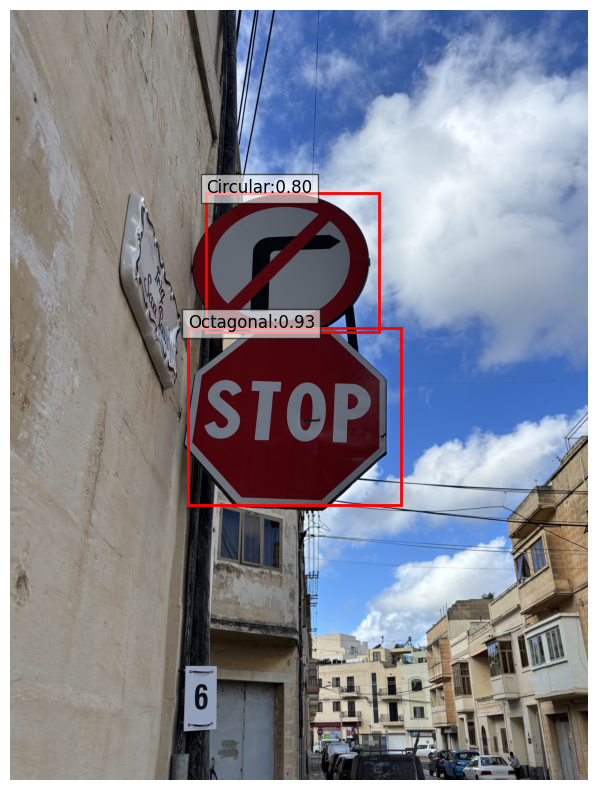

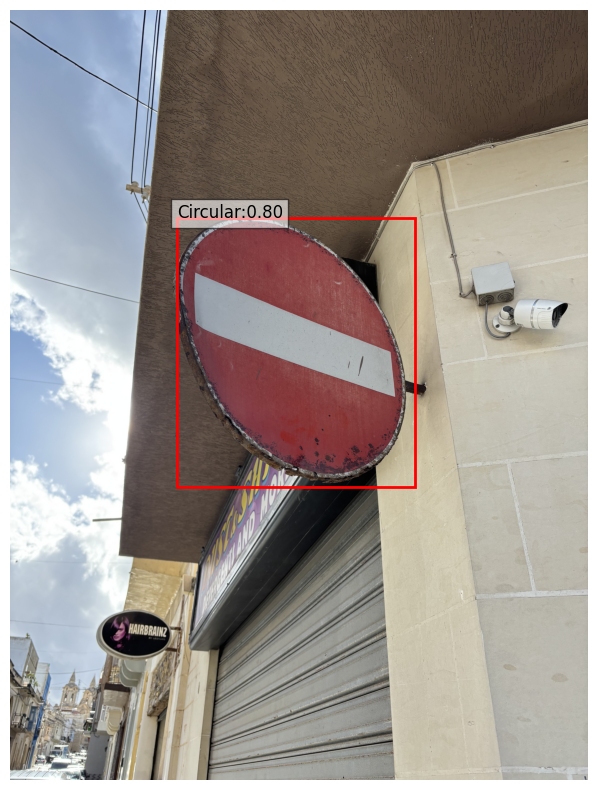

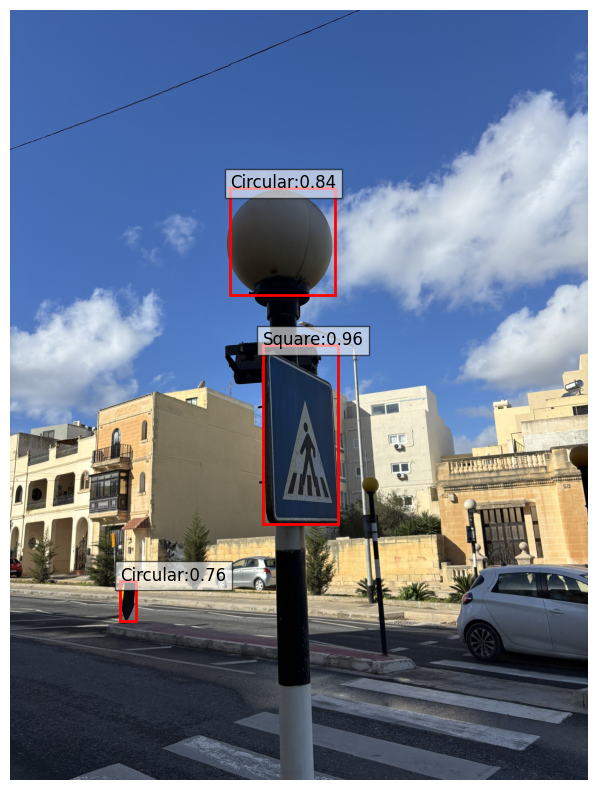

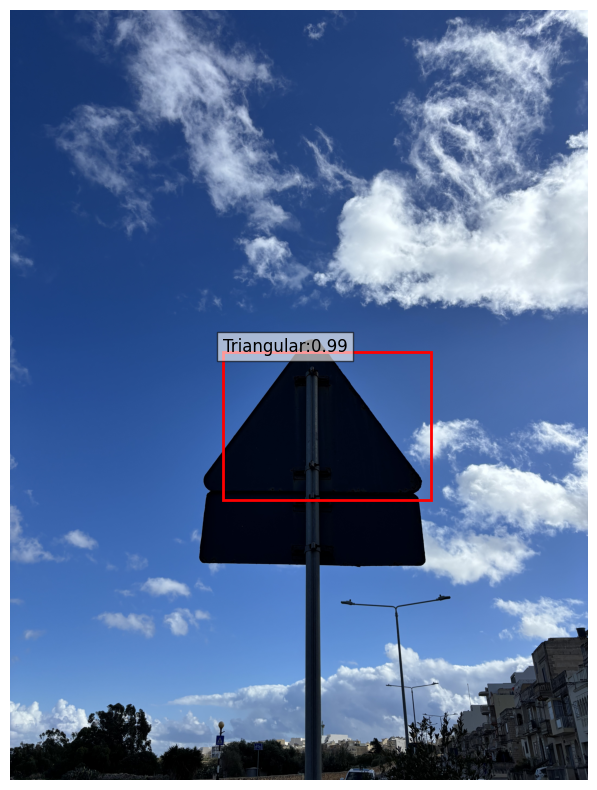

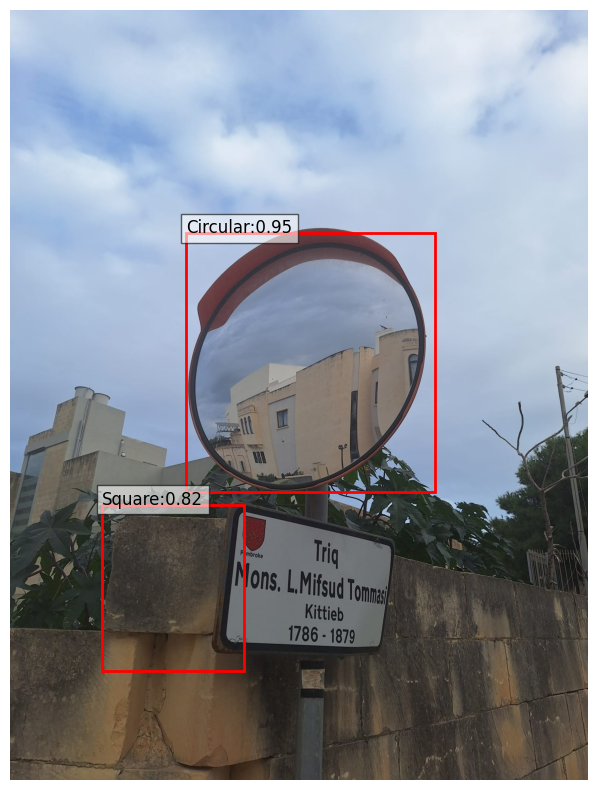

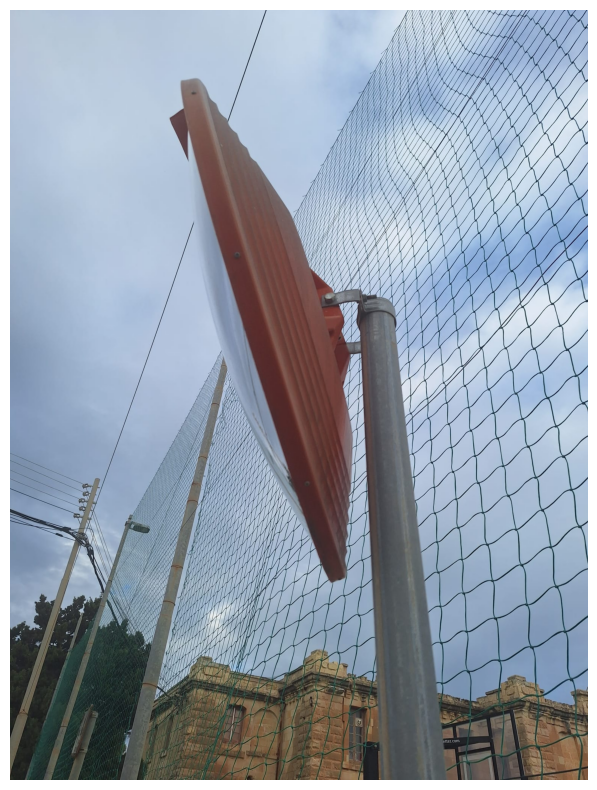

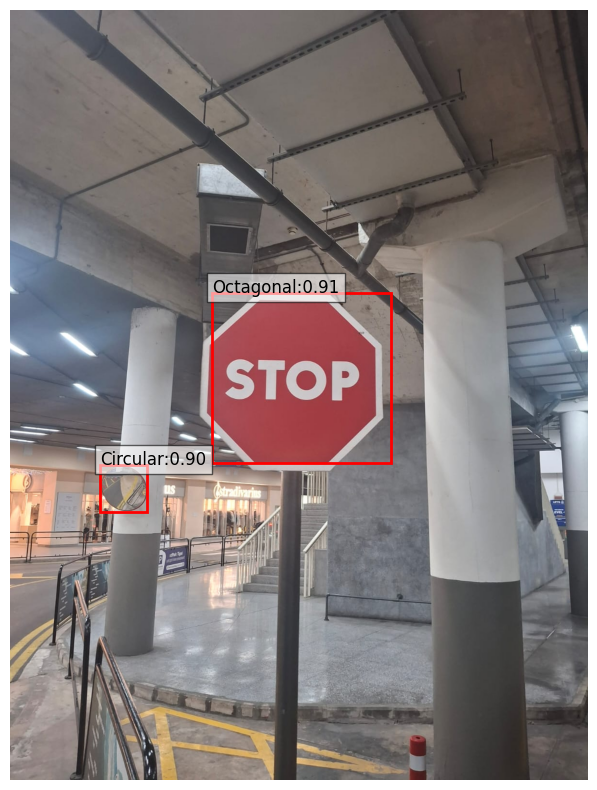

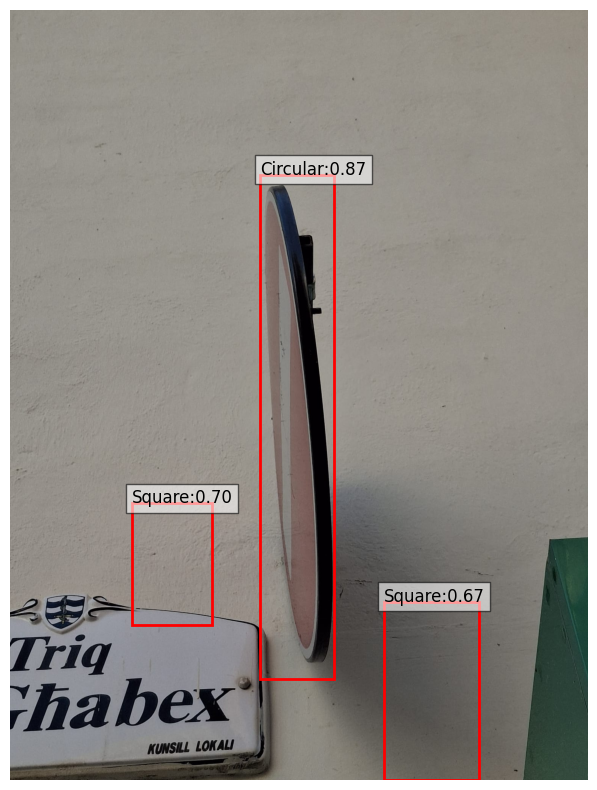

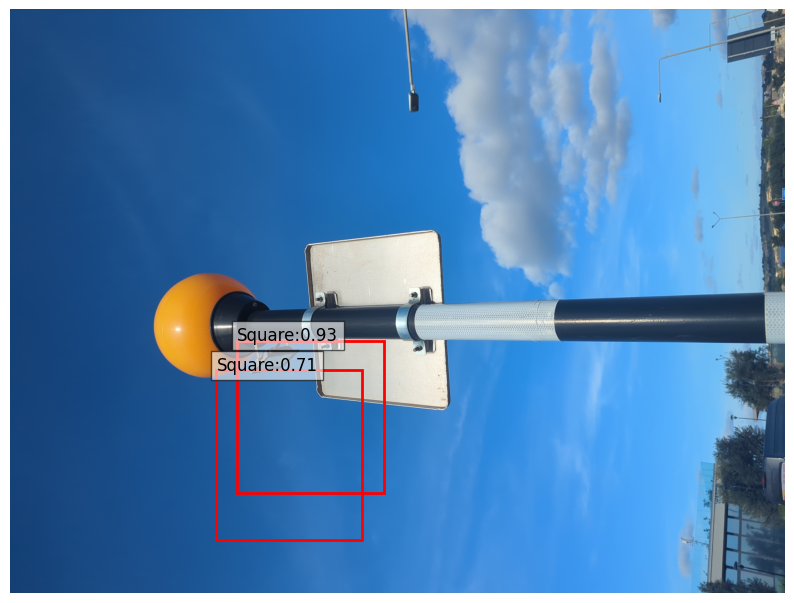

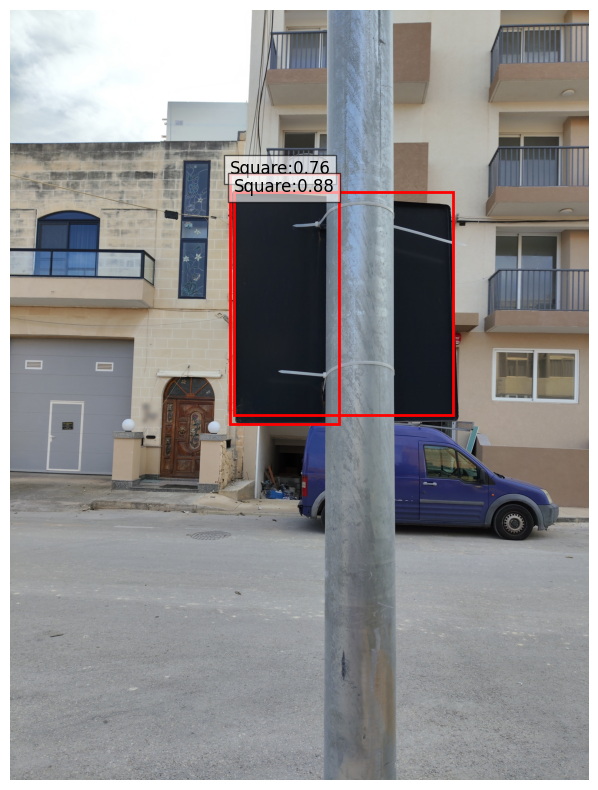

In [ ]:
@torch.no_grad()
def predict_image(model, img_path, score_thresh=0.5):   # note: no non-maximum suppression to compare w RF-DETR
    model.eval()
    img = Image.open(img_path).convert("RGB")
    x, _ = get_val_transforms()(img, {"boxes": torch.zeros((0,4)), "labels": torch.zeros((0,), dtype=torch.int64)})
    x = x.to(DEVICE)
    out = model([x])[0]

    keep = out["scores"] >= score_thresh
    boxes = out["boxes"][keep].detach().cpu().numpy()
    labels = out["labels"][keep].detach().cpu().numpy()
    scores = out["scores"][keep].detach().cpu().numpy()

    predns = list(zip(boxes, labels, scores))
    predns.sort(key=lambda x: x[2])   # sort by score to display highest conf on top

    # Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()
    for (x1, y1, x2, y2), lab, sc in predns:
        ax.add_patch(ptch.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2, ec='red'))
        name = ID2SHAPE.get(int(lab), str(int(lab)))
        ax.text(x1, y1, f"{name}:{sc:.2f}", fontsize=12, bbox=dict(facecolor="white", alpha=0.6))
    plt.axis("off")
    plt.show()

ims = [r"coco_set\coco_sign_shape\test\IMG_1506.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1517.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1532.jpg",
       r"coco_set\coco_sign_shape\test\IMG_1550.jpg",
       r"coco_set\coco_sign_shape\valid\WhatsApp_Image_2025-11-20_at_16.02.59__2_.jpeg",
       r"coco_set\coco_sign_shape\valid\WhatsApp_Image_2025-11-20_at_16.02.59.jpeg",
       r"coco_set\coco_sign_shape\valid\WhatsApp_Image_2025-11-20_at_16.56.49__2_.jpeg",
       r"coco_set\coco_sign_shape\valid\WhatsApp_Image_2025-11-16_at_17.52.25.jpeg",
       r"coco_set\coco_sign_shape\valid\IMG_20260113_084953_901.jpg",
       r"coco_set\coco_sign_shape\valid\IMG_20251125_123922.jpg"]

# Examples:
for im in ims:
    predict_image(model, im, score_thresh=0.5)


## Set Distribution

In [57]:
import pandas as pd

def dataset_to_df(dataset):
    rows = []

    for idx in range(len(dataset)):
        img, t = dataset[idx]  # img is unused here, but you can read its shape if needed

        boxes = t["boxes"].detach().cpu().numpy()
        labels = t["labels"].detach().cpu().numpy()

        # optional: image_id if you store it
        image_id = int(t["image_id"].item()) if "image_id" in t else idx

        for box, lbl in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box
            rows.append({
                "dataset_index": idx,
                "image_id": image_id,
                "label": ID2SHAPE.get(int(lbl), str(int(lbl)))
            })

    return pd.DataFrame(rows)


In [58]:
train_df = dataset_to_df(train_ds)
val_df = dataset_to_df(val_ds)
test_df = dataset_to_df(test_ds)

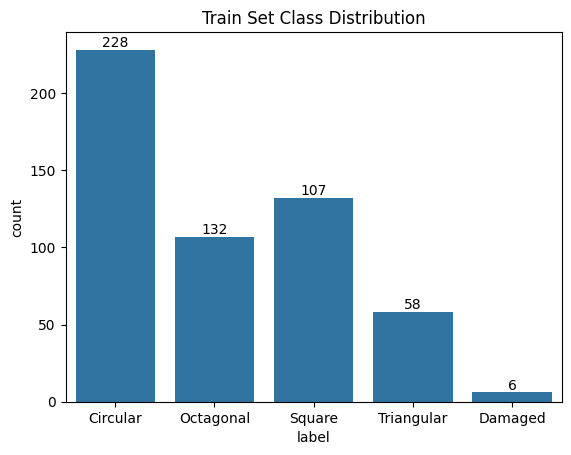

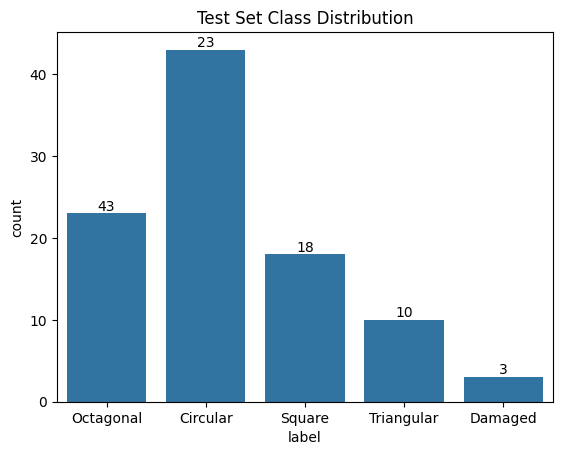

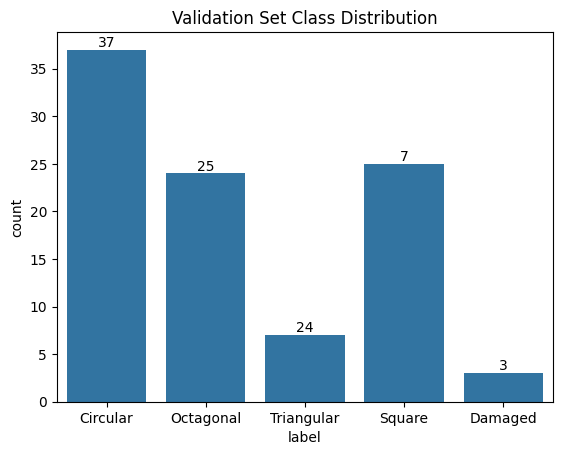

In [59]:
import seaborn as sns
def plot_counts(df):
    ax = sns.countplot(df, x="label")
    abs_values = df["label"].value_counts().values
    ax.bar_label(container=ax.containers[0], labels=abs_values)
    return ax
plot_counts(train_df).set_title("Train Set Class Distribution")
plt.show()
plot_counts(test_df).set_title("Test Set Class Distribution")
plt.show()
plot_counts(val_df).set_title("Validation Set Class Distribution")
plt.show()